# **Climate Forecasting using Machine Learning: 03 Training And Selection Strategy**

---

### **Notebook Summary**

This notebook tunes the training and model-selection strategy after notebook 02 identifies the feature recipe to carry forward. The first section tests whether recent observations should receive more weight during model fitting. The second section tests whether validation-selected model choice should happen globally, by broad seasonal groups, or month-by-month.

### **Strategy settings**
- H = 1
- AR + ENSO features
- SST off
- QMAP off
- retained model set fixed
- recency strategy varied first
- month-group selection varied second
- random seed = 42

### **What this notebook should answer**
1. Does recency weighting improve held-out performance?
2. Which recency half-life should be carried forward?
3. Does grouped month selection improve over one annual/global model choice?
4. Which month-group size should be carried into temporal feature tuning?

---

# **Part 1: Configuration**

### **Imports**

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    return next(
        candidate
        for candidate in [start, *start.parents]
        if (candidate / "src" / "forecaster" / "__init__.py").exists()
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR))


def project_relative(path):
    return Path(path).resolve().relative_to(PROJECT_ROOT).as_posix()


def portable_config(config):
    portable = dict(vars(config)) if hasattr(config, "__dict__") else dict(config)

    for key in ("tavg_file", "sst_dir", "enso_csv"):
        if key in portable and portable[key] is not None:
            portable[key] = project_relative(portable[key])

    return portable


from forecaster.config import ForecasterConfig
from forecaster.pipeline import run_backtest
from forecaster.data.sources import (
    load_land_series_and_anoms,
    load_enso_monthly,
    load_teleconnections,
)
from forecaster.data.sst import load_multi_region_sst_pcs
from forecaster.experiments import summarize_run as _summarize_run
from forecaster.ml.core import build_features_and_target, train_predict_models
from forecaster.ml.evaluation import overall_table, eval_by_month, rmse, mae, bias
from forecaster.ml.selection import (
    build_contiguous_month_groups,
    build_group_member_map,
    build_strategy_table,
    make_seasonal_ensemble_prediction,
    rank_models_in_group,
)


pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

print("Repository setup complete.")
print("Import path: src")

Repository setup complete.
Import path: src


### **Figure export helper**

Plots saved by this notebook are written to the shared case-analysis image folder so the final Markdown report can reference stable figure files.

In [2]:
IMAGE_DIR = PROJECT_ROOT / "experiment_notebooks/Experiment_Images_For_Case_Analysis"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def save_current_plot(filename: str, *, dpi: int = 180):
    path = IMAGE_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("Saved figure:", path.relative_to(PROJECT_ROOT))
    return path


print("Case-analysis image folder:", IMAGE_DIR.relative_to(PROJECT_ROOT))

Case-analysis image folder: experiment_notebooks/Experiment_Images_For_Case_Analysis


### **Configure local data paths**

This cell points the notebook at the local NOAA temperature file, SST cache, and ENSO CSV. The existence checks catch missing inputs before any long backtests run.

In [3]:
DATA_DIR = PROJECT_ROOT / "noaa_raw_data"
TAVG_FILE = str(DATA_DIR / "nclimgrid_tavg.nc")
SST_DIR = str(DATA_DIR / "sst_cache")
ENSO_CSV = str(DATA_DIR / "nina34.anom.csv")
RANDOM_SEED = 42

for name, p in [("TAVG_FILE", TAVG_FILE), ("SST_DIR", SST_DIR), ("ENSO_CSV", ENSO_CSV)]:
    print(f"{name}: {project_relative(p)} -> {Path(p).exists()}")

TAVG_FILE: nclimgrid_tavg.nc -> True
SST_DIR: sst_cache -> True
ENSO_CSV: nina34.anom.csv -> True


### **Extend the feature setup selected in 02**

The feature-ablation notebook is the source of truth for which feature combinations were tested. This section loads the saved 02 leaderboard, uses the validation-selected AR + ENSO run from 02 and keeps that feature setup fixed while testing recency weights.

In [4]:
ABLATION_LEADERBOARD_PATH = PROJECT_ROOT / "notebooks_outputs" / "02_feature_ablation_leaderboard.csv"

ablation_leaderboard = pd.read_csv(ABLATION_LEADERBOARD_PATH)

selected_feature_run = "AR_plus_enso"

FEATURE_OVERRIDES = {
    "use_teleconnections": False,
    "use_sst": False,
    "enso_csv": ENSO_CSV,
}

RESEARCH_MODEL_SET = [
    "Ridge",
    "Huber",
    "XGBoost",
    "LSTM",
    "PatchTST",
    "iTransformer",
    "NHiTS",
]

BASE_CFG = {
    "tavg_file": TAVG_FILE,
    "sst_dir": SST_DIR,
    "random_seed": RANDOM_SEED,

    # Keep decision layers off for clean comparisons
    "use_qmap": False,
    "use_month_alpha_choice": False,

    # Research model set
    "use_ridge": True,
    "use_huber": True,
    "use_xgb": True,
    "use_lstm": True,
    "use_patchtst": True,
    "use_itransformer": True,
    "use_nhits": True,

    # Fixed forecasting horizon
    "H": 1,

    "plot_test": False,
    "verbose": True,
}

BASE_CFG.update(FEATURE_OVERRIDES)

print(f"Carry-forward feature setup: {selected_feature_run}")
print(f"Feature overrides: {portable_config(FEATURE_OVERRIDES)}")
print(f"Research model set: {RESEARCH_MODEL_SET}")

Carry-forward feature setup: AR_plus_enso
Feature overrides: {'use_teleconnections': False, 'use_sst': False, 'enso_csv': 'nina34.anom.csv'}
Research model set: ['Ridge', 'Huber', 'XGBoost', 'LSTM', 'PatchTST', 'iTransformer', 'NHiTS']


### **Define the recency-weighting runs**

All rows use the selected AR + ENSO setup from 02. Only use_recency_weights and half_life_months vary, which isolates the effect of weighting recent observations more heavily.

In [5]:
RECENCY_RUNS = [
    ("no_recency_weights", dict(use_recency_weights=False)),
    ("half_life_24m", dict(use_recency_weights=True, half_life_months=24.0)),
    ("half_life_48m", dict(use_recency_weights=True, half_life_months=48.0)),
    ("half_life_96m", dict(use_recency_weights=True, half_life_months=96.0)),
    ("half_life_240m", dict(use_recency_weights=True, half_life_months=240.0)),
]

RECENCY_RUNS

[('no_recency_weights', {'use_recency_weights': False}),
 ('half_life_24m', {'use_recency_weights': True, 'half_life_months': 24.0}),
 ('half_life_48m', {'use_recency_weights': True, 'half_life_months': 48.0}),
 ('half_life_96m', {'use_recency_weights': True, 'half_life_months': 96.0}),
 ('half_life_240m', {'use_recency_weights': True, 'half_life_months': 240.0})]

### **Helper: summarize each run**

This helper turns each full backtest into one leaderboard row. It keeps the validation-selected model, that model's test result, and the deltas versus the baseline so every recency setting can be compared consistently.

In [6]:
def summarize_recency_run(rr, label: str) -> dict:
    base = _summarize_run(rr, label, prefer_month_choice=False)
    return {
        "run": label,
        "val_best_model": base["global_val_best_model"],
        "val_rmse": base["global_val_rmse"],
        "val_mae": base["global_val_mae"],
        "test_rmse": base["test_rmse"],
        "test_mae": base["test_mae"],
        "test_bias": base["test_bias"],
        "baseline_test_rmse": base.get("baseline_test_rmse", np.nan),
        "baseline_test_mae": base.get("baseline_test_mae", np.nan),
        "dRMSE_vs_baseline": base.get("dRMSE_vs_baseline", np.nan),
        "dMAE_vs_baseline": base.get("dMAE_vs_baseline", np.nan),
        "run_id": base["run_id"],
    }

---

# **Part 2: Run the recency-weighting experiments**

### **Run Experiment**

In [7]:
recency_results = []
recency_run_objects = {}

valid_cfg_keys = set(ForecasterConfig.__dataclass_fields__.keys())

for label, overrides in RECENCY_RUNS:
    print("=" * 90)
    print(f"Running recency experiment: {label}")
    raw_cfg = {**BASE_CFG, **overrides}
    ignored_keys = sorted(set(raw_cfg) - valid_cfg_keys)
    if ignored_keys:
        print(f"Ignoring unsupported config keys: {ignored_keys}")
    cfg = ForecasterConfig(**{k: v for k, v in raw_cfg.items() if k in valid_cfg_keys})
    rr = run_backtest(cfg)

    recency_run_objects[label] = rr
    recency_results.append(summarize_recency_run(rr, label))

print("/nFinished all recency-weighting runs.")

Running recency experiment: no_recency_weights
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running recency experiment: half_life_24m
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running recency experiment: half_life_48m
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running recency experiment: half_life_96m
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running recency experiment: half_life_240m
[BOOT] Starting backtest

==

---

# **Part 3: Recency-Weighting Results**

### **Recency leaderboard**

This is the main summary table for choosing a half-life. Each row reports the validation-selected model for one recency strategy and that model's test metrics.

In [8]:
recency_results_df = pd.DataFrame(recency_results)

recency_leaderboard = (
    recency_results_df
    .sort_values(["test_rmse", "test_mae", "val_rmse"])
    .reset_index(drop=True)
)

recency_leaderboard

,run,val_best_model,val_rmse,val_mae,test_rmse,test_mae,test_bias,baseline_test_rmse,baseline_test_mae,dRMSE_vs_baseline,dMAE_vs_baseline,run_id
0,half_life_48m,NHiTS,1.061779,0.837982,1.202017,0.973281,-0.382734,1.337108,1.0011,-0.135091,-0.027819,runs/official_backtest_20260820_202847_utc
1,half_life_240m,NHiTS,1.086453,0.846645,1.205241,0.972382,-0.393320,1.337108,1.0011,-0.131867,-0.028718,runs/official_backtest_20260820_203232_utc
2,half_life_96m,NHiTS,1.073532,0.849850,1.208763,0.978401,-0.393160,1.337108,1.0011,-0.128346,-0.022699,runs/official_backtest_20260820_203037_utc
3,half_life_24m,NHiTS,1.062554,0.837104,1.210240,0.987674,-0.414771,1.337108,1.0011,-0.126868,-0.013426,runs/official_backtest_20260820_202706_utc
4,no_recency_weights,iTransformer,1.086278,0.858319,1.232080,1.018901,-0.367083,1.337108,1.0011,-0.105029,0.017801,runs/official_backtest_20260820_202528_utc


### **Validation-sorted and test-sorted views**

These views show whether the same half-life looks best before and after moving to the held-out test period.

In [9]:
print("Validation-sorted view")
display(
    recency_results_df.sort_values(["val_rmse", "val_mae"]).reset_index(drop=True)
)

print("Test-sorted view")
display(
    recency_results_df.sort_values(["test_rmse", "test_mae"]).reset_index(drop=True)
)

Validation-sorted view


,run,val_best_model,val_rmse,val_mae,test_rmse,test_mae,test_bias,baseline_test_rmse,baseline_test_mae,dRMSE_vs_baseline,dMAE_vs_baseline,run_id
0,half_life_48m,NHiTS,1.061779,0.837982,1.202017,0.973281,-0.382734,1.337108,1.0011,-0.135091,-0.027819,runs/official_backtest_20260820_202847_utc
1,half_life_24m,NHiTS,1.062554,0.837104,1.210240,0.987674,-0.414771,1.337108,1.0011,-0.126868,-0.013426,runs/official_backtest_20260820_202706_utc
2,half_life_96m,NHiTS,1.073532,0.849850,1.208763,0.978401,-0.393160,1.337108,1.0011,-0.128346,-0.022699,runs/official_backtest_20260820_203037_utc
3,no_recency_weights,iTransformer,1.086278,0.858319,1.232080,1.018901,-0.367083,1.337108,1.0011,-0.105029,0.017801,runs/official_backtest_20260820_202528_utc
4,half_life_240m,NHiTS,1.086453,0.846645,1.205241,0.972382,-0.393320,1.337108,1.0011,-0.131867,-0.028718,runs/official_backtest_20260820_203232_utc


Test-sorted view


,run,val_best_model,val_rmse,val_mae,test_rmse,test_mae,test_bias,baseline_test_rmse,baseline_test_mae,dRMSE_vs_baseline,dMAE_vs_baseline,run_id
0,half_life_48m,NHiTS,1.061779,0.837982,1.202017,0.973281,-0.382734,1.337108,1.0011,-0.135091,-0.027819,runs/official_backtest_20260820_202847_utc
1,half_life_240m,NHiTS,1.086453,0.846645,1.205241,0.972382,-0.393320,1.337108,1.0011,-0.131867,-0.028718,runs/official_backtest_20260820_203232_utc
2,half_life_96m,NHiTS,1.073532,0.849850,1.208763,0.978401,-0.393160,1.337108,1.0011,-0.128346,-0.022699,runs/official_backtest_20260820_203037_utc
3,half_life_24m,NHiTS,1.062554,0.837104,1.210240,0.987674,-0.414771,1.337108,1.0011,-0.126868,-0.013426,runs/official_backtest_20260820_202706_utc
4,no_recency_weights,iTransformer,1.086278,0.858319,1.232080,1.018901,-0.367083,1.337108,1.0011,-0.105029,0.017801,runs/official_backtest_20260820_202528_utc


### **Best recency strategy**

This cell isolates the strongest recency row so the downstream notebooks have a clear carry-forward setting.

In [10]:
best_strategy = recency_leaderboard.iloc[0]
best_strategy

run                                                half_life_48m
val_best_model                                             NHiTS
val_rmse                                                1.061779
val_mae                                                 0.837982
test_rmse                                               1.202017
test_mae                                                0.973281
test_bias                                              -0.382734
baseline_test_rmse                                      1.337108
baseline_test_mae                                         1.0011
dRMSE_vs_baseline                                      -0.135091
dMAE_vs_baseline                                       -0.027819
run_id                runs/official_backtest_20260820_202847_utc
Name: 0, dtype: object

### **Carry forward the selected recency strategy**

This cell applies the selected recency setting before grouped-selection experiments begin. The grouped-selection section therefore builds on the first section instead of restarting with implicit defaults.

In [11]:
best_recency_label = str(best_strategy["run"])
CARRY_FORWARD_RECENCY_OVERRIDES = dict(RECENCY_RUNS)[best_recency_label]
BASE_CFG.update(CARRY_FORWARD_RECENCY_OVERRIDES)

print("Carry-forward recency strategy:", best_recency_label)
print("Carry-forward recency overrides:", CARRY_FORWARD_RECENCY_OVERRIDES)
portable_config(BASE_CFG)

Carry-forward recency strategy: half_life_48m
Carry-forward recency overrides: {'use_recency_weights': True, 'half_life_months': 48.0}


{'tavg_file': 'nclimgrid_tavg.nc',
 'sst_dir': 'sst_cache',
 'random_seed': 42,
 'use_qmap': False,
 'use_month_alpha_choice': False,
 'use_ridge': True,
 'use_huber': True,
 'use_xgb': True,
 'use_lstm': True,
 'use_patchtst': True,
 'use_itransformer': True,
 'use_nhits': True,
 'H': 1,
 'plot_test': False,
 'verbose': True,
 'use_teleconnections': False,
 'use_sst': False,
 'enso_csv': 'nina34.anom.csv',
 'use_recency_weights': True,
 'half_life_months': 48.0}

### **Plot: test RMSE by recency strategy**

Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/03_training_strategy_recency_test_rmse_by_strategy.png


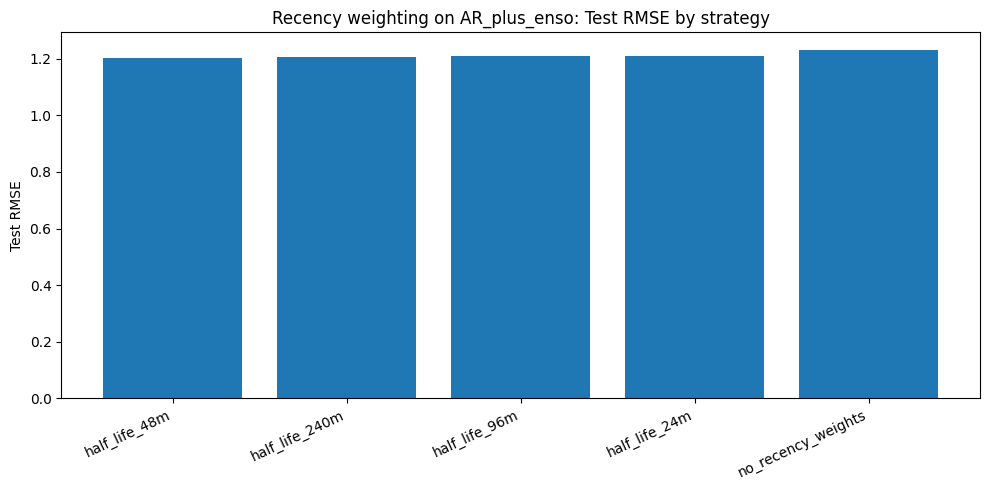

In [12]:
plot_df = recency_leaderboard.sort_values("test_rmse").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["run"], plot_df["test_rmse"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Test RMSE")
plt.title(f"Recency weighting on {selected_feature_run}: Test RMSE by strategy")
plt.tight_layout()
save_current_plot("03_training_strategy_recency_test_rmse_by_strategy.png")
plt.show()

### **Compare each strategy against the no-weighting reference**

This table measures the direct value of recency weighting. Negative deltas mean the weighted strategy has lower error than the unweighted run.

In [13]:
reference_row = recency_results_df.loc[recency_results_df["run"] == "no_recency_weights"].iloc[0]

ref_rmse = float(reference_row["test_rmse"])
ref_mae = float(reference_row["test_mae"])

recency_results_df["dRMSE_vs_no_weighting"] = recency_results_df["test_rmse"] - ref_rmse
recency_results_df["dMAE_vs_no_weighting"] = recency_results_df["test_mae"] - ref_mae

delta_view = (
    recency_results_df[
        [
            "run",
            "val_best_model",
            "test_rmse",
            "test_mae",
            "dRMSE_vs_no_weighting",
            "dMAE_vs_no_weighting",
        ]
    ]
    .sort_values(["dRMSE_vs_no_weighting", "dMAE_vs_no_weighting"])
    .reset_index(drop=True)
)

print("Recency delta table relative to no_recency_weights")
display(delta_view)

Recency delta table relative to no_recency_weights


,run,val_best_model,test_rmse,test_mae,dRMSE_vs_no_weighting,dMAE_vs_no_weighting
0,half_life_48m,NHiTS,1.202017,0.973281,-0.030063,-0.045620
1,half_life_240m,NHiTS,1.205241,0.972382,-0.026839,-0.046519
2,half_life_96m,NHiTS,1.208763,0.978401,-0.023317,-0.040500
3,half_life_24m,NHiTS,1.210240,0.987674,-0.021839,-0.031227
4,no_recency_weights,iTransformer,1.232080,1.018901,0.000000,0.000000


### **Full overall validation tables for each run**

In [14]:
for label, rr in recency_run_objects.items():
    print(f"/n{label} : FULL VAL TABLE")
    display(rr.overall_val.copy().sort_values(["RMSE", "MAE"]).reset_index(drop=True))


no_recency_weights : FULL VAL TABLE


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,iTransformer,1.086278,0.858319,-0.298665,0.177083,0.208333,0.333333
1,NHiTS,1.102623,0.843485,-0.348213,0.218750,0.291667,0.354167
2,PatchTST,1.144045,0.888106,-0.400986,0.187500,0.239583,0.364583
3,XGBoost,1.147270,0.902527,-0.390455,0.166667,0.218750,0.395833
4,LSTM,1.161570,0.903100,-0.468549,0.197917,0.239583,0.333333
5,Huber,1.176403,0.905061,-0.439004,0.208333,0.281250,0.343750
6,Baseline,1.179166,0.893356,-0.076121,0.208333,0.302083,0.375000
7,Ridge,1.190991,0.903487,-0.474882,0.208333,0.281250,0.322917



half_life_24m : FULL VAL TABLE


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,NHiTS,1.062554,0.837104,-0.271675,0.135417,0.302083,0.354167
1,Ridge,1.064593,0.861359,-0.273844,0.156250,0.229167,0.364583
2,LSTM,1.098047,0.877744,-0.347781,0.135417,0.239583,0.333333
3,PatchTST,1.111707,0.861515,-0.026918,0.229167,0.281250,0.395833
4,iTransformer,1.126746,0.885539,-0.341253,0.125000,0.239583,0.385417
5,Huber,1.142315,0.893043,-0.303848,0.197917,0.250000,0.322917
6,Baseline,1.179166,0.893356,-0.076121,0.208333,0.302083,0.375000
7,XGBoost,1.199904,0.961894,-0.273064,0.135417,0.208333,0.302083



half_life_48m : FULL VAL TABLE


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,NHiTS,1.061779,0.837982,-0.270408,0.187500,0.291667,0.375000
1,Ridge,1.075594,0.864756,-0.278316,0.145833,0.250000,0.375000
2,Huber,1.093781,0.859721,-0.269665,0.208333,0.250000,0.364583
3,PatchTST,1.103924,0.851158,-0.183310,0.166667,0.281250,0.395833
4,LSTM,1.117865,0.896723,-0.352567,0.114583,0.197917,0.354167
5,iTransformer,1.125052,0.878556,-0.269143,0.135417,0.239583,0.375000
6,Baseline,1.179166,0.893356,-0.076121,0.208333,0.302083,0.375000
7,XGBoost,1.186545,0.937962,-0.355724,0.166667,0.239583,0.364583



half_life_96m : FULL VAL TABLE


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,NHiTS,1.073532,0.849850,-0.306890,0.187500,0.250000,0.343750
1,Ridge,1.090332,0.861530,-0.308709,0.218750,0.281250,0.354167
2,iTransformer,1.096658,0.854776,-0.191667,0.208333,0.260417,0.333333
3,Huber,1.101785,0.864237,-0.299395,0.166667,0.281250,0.375000
4,PatchTST,1.106042,0.861817,-0.247137,0.187500,0.260417,0.364583
5,LSTM,1.125871,0.892564,-0.360199,0.145833,0.208333,0.333333
6,XGBoost,1.166682,0.914206,-0.360332,0.177083,0.218750,0.343750
7,Baseline,1.179166,0.893356,-0.076121,0.208333,0.302083,0.375000



half_life_240m : FULL VAL TABLE


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,NHiTS,1.086453,0.846645,-0.336031,0.177083,0.270833,0.375000
1,iTransformer,1.092211,0.859795,-0.259572,0.166667,0.260417,0.375000
2,PatchTST,1.122354,0.881247,-0.340800,0.166667,0.239583,0.343750
3,Huber,1.123770,0.868768,-0.343518,0.239583,0.302083,0.364583
4,Ridge,1.131356,0.869159,-0.376028,0.250000,0.302083,0.354167
5,LSTM,1.137471,0.893429,-0.400959,0.187500,0.250000,0.343750
6,XGBoost,1.164985,0.916787,-0.422416,0.125000,0.229167,0.385417
7,Baseline,1.179166,0.893356,-0.076121,0.208333,0.302083,0.375000


### **Full overall test tables for each run**

In [15]:
for label, rr in recency_run_objects.items():
    print(f"/n{label} : FULL TEST TABLE")
    display(rr.overall_test.copy().sort_values(["RMSE", "MAE"]).reset_index(drop=True))


no_recency_weights : FULL TEST TABLE


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,NHiTS,1.201079,0.964262,-0.387099,0.157895,0.210526,0.273684
1,PatchTST,1.205537,0.957058,-0.405058,0.147368,0.231579,0.305263
2,LSTM,1.227823,0.991713,-0.480569,0.105263,0.178947,0.252632
3,iTransformer,1.232080,1.018901,-0.367083,0.115789,0.200000,0.294737
4,Huber,1.249987,1.023454,-0.511091,0.126316,0.157895,0.252632
5,Ridge,1.253964,1.024329,-0.537518,0.126316,0.147368,0.252632
6,XGBoost,1.312187,1.061080,-0.469042,0.168421,0.231579,0.263158
7,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526



half_life_24m : FULL TEST TABLE


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,NHiTS,1.210240,0.987674,-0.414771,0.136842,0.157895,0.273684
1,LSTM,1.226155,0.975669,-0.403214,0.189474,0.221053,0.326316
2,iTransformer,1.235730,1.008876,-0.491778,0.115789,0.147368,0.231579
3,Ridge,1.245881,1.004122,-0.373003,0.084211,0.168421,0.284211
4,PatchTST,1.247533,0.969537,-0.095279,0.210526,0.263158,0.336842
5,Huber,1.265770,0.987121,-0.488810,0.168421,0.242105,0.305263
6,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526
7,XGBoost,1.357658,1.095086,-0.410483,0.147368,0.178947,0.252632



half_life_48m : FULL TEST TABLE


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,PatchTST,1.177713,0.932456,-0.260849,0.189474,0.273684,0.347368
1,NHiTS,1.202017,0.973281,-0.382734,0.147368,0.210526,0.294737
2,iTransformer,1.205905,0.974722,-0.415567,0.115789,0.178947,0.315789
3,Huber,1.222309,0.964794,-0.418343,0.189474,0.210526,0.336842
4,Ridge,1.226889,0.991447,-0.399937,0.084211,0.189474,0.273684
5,LSTM,1.237365,1.001151,-0.428307,0.157895,0.210526,0.273684
6,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526
7,XGBoost,1.362837,1.105808,-0.408275,0.115789,0.178947,0.273684



half_life_96m : FULL TEST TABLE


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,PatchTST,1.188062,0.942392,-0.307657,0.157895,0.242105,0.347368
1,iTransformer,1.188161,0.952078,-0.322247,0.168421,0.231579,0.336842
2,NHiTS,1.208763,0.978401,-0.393160,0.136842,0.210526,0.294737
3,Ridge,1.212901,0.982218,-0.400125,0.136842,0.221053,0.273684
4,Huber,1.218610,0.978134,-0.406499,0.136842,0.200000,0.284211
5,LSTM,1.223268,1.000398,-0.426676,0.136842,0.189474,0.252632
6,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526
7,XGBoost,1.344643,1.092106,-0.376946,0.147368,0.200000,0.242105



half_life_240m : FULL TEST TABLE


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,PatchTST,1.200232,0.954370,-0.363038,0.157895,0.221053,0.326316
1,iTransformer,1.200631,0.981650,-0.359726,0.147368,0.242105,0.326316
2,NHiTS,1.205241,0.972382,-0.393320,0.147368,0.200000,0.294737
3,Huber,1.217562,0.985645,-0.420636,0.157895,0.189474,0.284211
4,LSTM,1.218886,0.992580,-0.435633,0.105263,0.157895,0.273684
5,Ridge,1.219322,0.990999,-0.440972,0.147368,0.200000,0.242105
6,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526
7,XGBoost,1.339269,1.088437,-0.436552,0.178947,0.252632,0.315789


### **Save results to CSV**

In [16]:
out_dir = PROJECT_ROOT / "notebooks_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

recency_leaderboard_path = out_dir / "03_training_strategy_recency_leaderboard.csv"
results_path = out_dir / "03_training_strategy_recency_results.csv"

recency_leaderboard.to_csv(recency_leaderboard_path, index=False)
recency_results_df.to_csv(results_path, index=False)

print("Saved:", project_relative(recency_leaderboard_path))
print("Saved:", project_relative(results_path))

Saved: notebooks_outputs/03_training_strategy_recency_leaderboard.csv
Saved: notebooks_outputs/03_training_strategy_recency_results.csv


---

# **Part 4: Grouped Month-Selection Strategy**

The recency experiment fixes the training-weighting setup. This section keeps the same feature set and retained model set, then tests how much seasonal specialization should be used when selecting models.

### **Carry forward recency into grouped selection**

The grouped-selection sweep uses the feature setup and model set already defined above, plus the recency setting selected in Part 3. Only the month-group size changes in the next experiment.

In [17]:
GROUPED_BASE_CFG = {
    **BASE_CFG,
    "use_month_alpha_choice": True,
    "month_group_size": 3,
}

print("Grouped-selection base uses recency strategy:", best_recency_label)
print("Research model set:", RESEARCH_MODEL_SET)
GROUPED_BASE_CFG

Grouped-selection base uses recency strategy: half_life_48m
Research model set: ['Ridge', 'Huber', 'XGBoost', 'LSTM', 'PatchTST', 'iTransformer', 'NHiTS']


{'tavg_file': 'nclimgrid_tavg.nc',
 'sst_dir': 'sst_cache',
 'random_seed': 42,
 'use_qmap': False,
 'use_month_alpha_choice': True,
 'use_ridge': True,
 'use_huber': True,
 'use_xgb': True,
 'use_lstm': True,
 'use_patchtst': True,
 'use_itransformer': True,
 'use_nhits': True,
 'H': 1,
 'plot_test': False,
 'verbose': True,
 'use_teleconnections': False,
 'use_sst': False,
 'enso_csv': 'nina34.anom.csv',
 'use_recency_weights': True,
 'half_life_months': 48.0,
 'month_group_size': 3}

### **Define the month-group experiments**

Each run changes the size of the month groups used for validation-based model choice. Smaller groups allow more seasonal specialization, while larger groups use more validation samples per decision.

In [18]:
GROUP_SIZES = [1, 2, 3, 4, 6, 12]
GROUP_SIZES

[1, 2, 3, 4, 6, 12]

### **Helper: summarize each run**

This helper reduces each grouped-selection backtest to comparable metrics. It records the selected final model/ensemble, validation error, test error, baseline error, and deltas versus the baseline.

In [19]:
def summarize_grouped_selection_run(rr, group_size: int) -> dict:
    base = _summarize_run(rr, group_size, label_field="month_group_size")
    return {
        "month_group_size": int(group_size),
        "final_model": base["final_model"],
        "chosen_models": base["chosen_models"],
        "global_val_best_model": base["global_val_best_model"],
        "global_val_rmse": base["global_val_rmse"],
        "global_val_mae": base["global_val_mae"],
        "test_rmse": base["test_rmse"],
        "test_mae": base["test_mae"],
        "test_bias": base["test_bias"],
        "baseline_test_rmse": base.get("baseline_test_rmse", np.nan),
        "baseline_test_mae": base.get("baseline_test_mae", np.nan),
        "dRMSE_vs_baseline": base.get("dRMSE_vs_baseline", np.nan),
        "dMAE_vs_baseline": base.get("dMAE_vs_baseline", np.nan),
        "run_id": base["run_id"],
    }

---

# **Part 5: Run the grouped-selection experiments**

### **Run Experiment**

In [20]:
grouped_results = []
grouped_run_objects = {}

valid_cfg_keys = set(ForecasterConfig.__dataclass_fields__.keys())

for g in GROUP_SIZES:
    print("=" * 90)
    print(f"Running grouped selection experiment: month_group_size={g}")

    raw_cfg = {**GROUPED_BASE_CFG, "month_group_size": g}
    ignored_keys = sorted(set(raw_cfg) - valid_cfg_keys)
    if ignored_keys:
        print(f"Ignoring unsupported config keys: {ignored_keys}")
    cfg = ForecasterConfig(**{k: v for k, v in raw_cfg.items() if k in valid_cfg_keys})
    rr = run_backtest(cfg)

    grouped_run_objects[g] = rr
    grouped_results.append(summarize_grouped_selection_run(rr, g))

print("/nFinished all grouped-selection runs.")

Running grouped selection experiment: month_group_size=1
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running grouped selection experiment: month_group_size=2
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running grouped selection experiment: month_group_size=3
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running grouped selection experiment: month_group_size=4
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running grouped 

---

# **Part 6: Grouped-Selection Results**

### **Grouped-selection leaderboard**

This table ranks the month-group strategies by the validation-selected final forecast and its held-out test performance.

In [21]:
grouped_results_df = pd.DataFrame(grouped_results)

grouped_leaderboard = (
    grouped_results_df
    .sort_values(["test_rmse", "test_mae"])
    .reset_index(drop=True)
)

grouped_leaderboard

,month_group_size,final_model,chosen_models,global_val_best_model,global_val_rmse,global_val_mae,test_rmse,test_mae,test_bias,baseline_test_rmse,baseline_test_mae,dRMSE_vs_baseline,dMAE_vs_baseline,run_id
0,2,Ensemble_MonthChoice,"Baseline, Huber, PatchTST, Ridge, iTransformer",NHiTS,1.061779,0.837982,1.185771,0.928219,-0.241850,1.337108,1.0011,-0.151338,-0.072880,runs/official_backtest_20260820_203631_utc
1,12,Ensemble_MonthChoice,NHiTS,NHiTS,1.061779,0.837982,1.202017,0.973281,-0.382734,1.337108,1.0011,-0.135091,-0.027819,runs/official_backtest_20260820_204345_utc
2,3,Ensemble_MonthChoice,"Huber, NHiTS, PatchTST, Ridge",NHiTS,1.061779,0.837982,1.205365,0.951686,-0.340616,1.337108,1.0011,-0.131743,-0.049413,runs/official_backtest_20260820_203821_utc
3,4,Ensemble_MonthChoice,"Huber, PatchTST, Ridge",NHiTS,1.061779,0.837982,1.208692,0.956475,-0.318528,1.337108,1.0011,-0.128416,-0.044625,runs/official_backtest_20260820_204012_utc
4,1,Ensemble_MonthChoice,"Baseline, Huber, NHiTS, PatchTST, Ridge, XGBoost",NHiTS,1.061779,0.837982,1.210470,0.927799,-0.239589,1.337108,1.0011,-0.126639,-0.073301,runs/official_backtest_20260820_203434_utc
5,6,Ensemble_MonthChoice,"NHiTS, Ridge",NHiTS,1.061779,0.837982,1.231933,0.995295,-0.388176,1.337108,1.0011,-0.105175,-0.005804,runs/official_backtest_20260820_204202_utc


### **Test-sorted views**

In [22]:
print("Test-sorted view")
display(
    grouped_results_df.sort_values(["test_rmse", "test_mae"]).reset_index(drop=True)
)

Test-sorted view


,month_group_size,final_model,chosen_models,global_val_best_model,global_val_rmse,global_val_mae,test_rmse,test_mae,test_bias,baseline_test_rmse,baseline_test_mae,dRMSE_vs_baseline,dMAE_vs_baseline,run_id
0,2,Ensemble_MonthChoice,"Baseline, Huber, PatchTST, Ridge, iTransformer",NHiTS,1.061779,0.837982,1.185771,0.928219,-0.241850,1.337108,1.0011,-0.151338,-0.072880,runs/official_backtest_20260820_203631_utc
1,12,Ensemble_MonthChoice,NHiTS,NHiTS,1.061779,0.837982,1.202017,0.973281,-0.382734,1.337108,1.0011,-0.135091,-0.027819,runs/official_backtest_20260820_204345_utc
2,3,Ensemble_MonthChoice,"Huber, NHiTS, PatchTST, Ridge",NHiTS,1.061779,0.837982,1.205365,0.951686,-0.340616,1.337108,1.0011,-0.131743,-0.049413,runs/official_backtest_20260820_203821_utc
3,4,Ensemble_MonthChoice,"Huber, PatchTST, Ridge",NHiTS,1.061779,0.837982,1.208692,0.956475,-0.318528,1.337108,1.0011,-0.128416,-0.044625,runs/official_backtest_20260820_204012_utc
4,1,Ensemble_MonthChoice,"Baseline, Huber, NHiTS, PatchTST, Ridge, XGBoost",NHiTS,1.061779,0.837982,1.210470,0.927799,-0.239589,1.337108,1.0011,-0.126639,-0.073301,runs/official_backtest_20260820_203434_utc
5,6,Ensemble_MonthChoice,"NHiTS, Ridge",NHiTS,1.061779,0.837982,1.231933,0.995295,-0.388176,1.337108,1.0011,-0.105175,-0.005804,runs/official_backtest_20260820_204202_utc


### **Best month grouping size**

This cell pulls out the strongest grouping configuration so it can be carried into later lag and ENSO experiments.

In [23]:
best_grouping = grouped_leaderboard.iloc[0]
best_grouping

month_group_size                                                      2
final_model                                        Ensemble_MonthChoice
chosen_models            Baseline, Huber, PatchTST, Ridge, iTransformer
global_val_best_model                                             NHiTS
global_val_rmse                                                1.061779
global_val_mae                                                 0.837982
test_rmse                                                      1.185771
test_mae                                                       0.928219
test_bias                                                      -0.24185
baseline_test_rmse                                             1.337108
baseline_test_mae                                                1.0011
dRMSE_vs_baseline                                             -0.151338
dMAE_vs_baseline                                               -0.07288
run_id                       runs/official_backtest_20260820_203

### **Plot: test RMSE by month grouping size**

Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/03_training_strategy_grouped_test_rmse_by_group_size.png


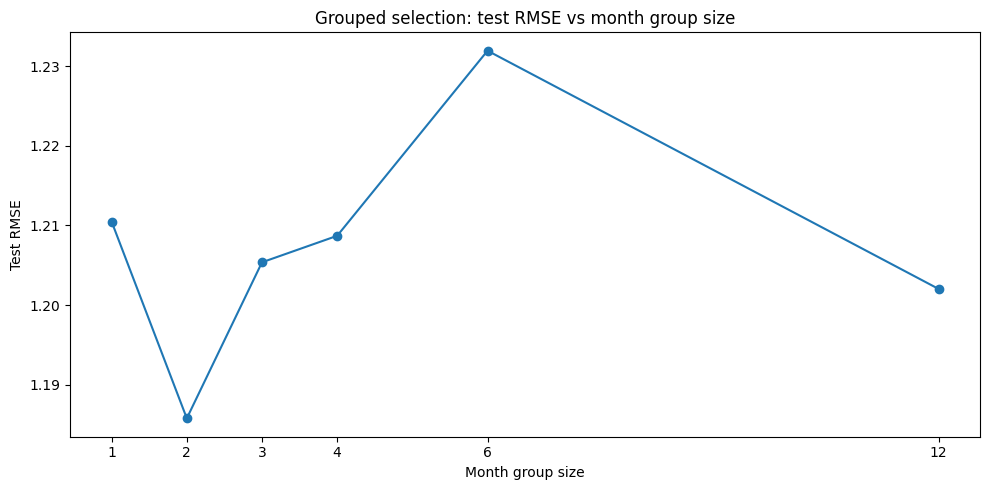

In [24]:
plot_df = grouped_results_df.sort_values("month_group_size").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(plot_df["month_group_size"], plot_df["test_rmse"], marker="o")
plt.xticks(plot_df["month_group_size"])
plt.xlabel("Month group size")
plt.ylabel("Test RMSE")
plt.title("Grouped selection: test RMSE vs month group size")
plt.tight_layout()
save_current_plot("03_training_strategy_grouped_test_rmse_by_group_size.png")
plt.show()

### **Plot: test MAE by month grouping size**

Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/03_training_strategy_grouped_test_mae_by_group_size.png


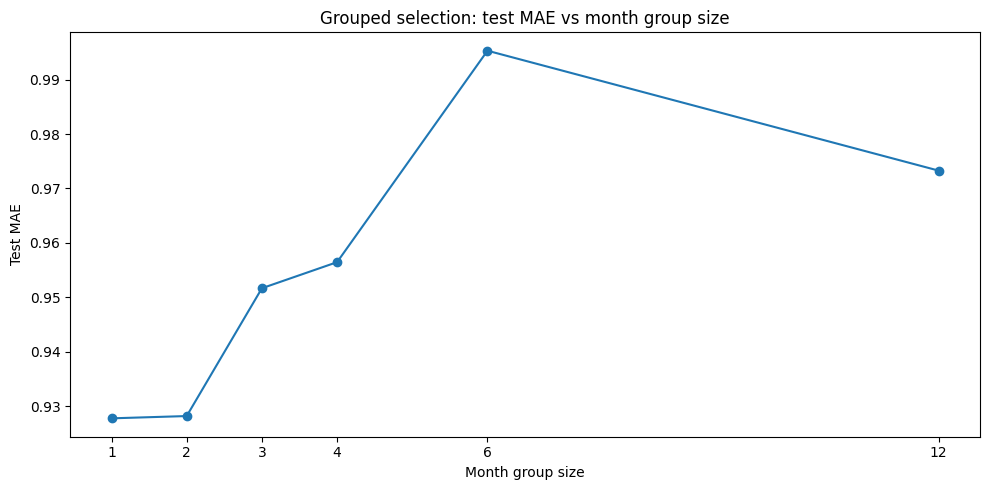

In [25]:
plot_df = grouped_results_df.sort_values("month_group_size").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(plot_df["month_group_size"], plot_df["test_mae"], marker="o")
plt.xticks(plot_df["month_group_size"])
plt.xlabel("Month group size")
plt.ylabel("Test MAE")
plt.title("Grouped selection: test MAE vs month group size")
plt.tight_layout()
save_current_plot("03_training_strategy_grouped_test_mae_by_group_size.png")
plt.show()

### **Compare each grouping size against the 12-month reference**

The 12-month setting behaves like one global annual model choice. This comparison shows whether seasonal grouping improves over that simpler reference.

In [26]:
reference_row = grouped_results_df.loc[grouped_results_df["month_group_size"] == 12].iloc[0]

ref_rmse = float(reference_row["test_rmse"])
ref_mae = float(reference_row["test_mae"])

grouped_results_df["dRMSE_vs_group12"] = grouped_results_df["test_rmse"] - ref_rmse
grouped_results_df["dMAE_vs_group12"] = grouped_results_df["test_mae"] - ref_mae

delta_view = (
    grouped_results_df[
        [
            "month_group_size",
            "test_rmse",
            "test_mae",
            "dRMSE_vs_group12",
            "dMAE_vs_group12",
        ]
    ]
    .sort_values(["dRMSE_vs_group12", "dMAE_vs_group12"])
    .reset_index(drop=True)
)

print("Grouped-selection delta table relative to month_group_size = 12")
display(delta_view)

Grouped-selection delta table relative to month_group_size = 12


,month_group_size,test_rmse,test_mae,dRMSE_vs_group12,dMAE_vs_group12
0,2,1.185771,0.928219,-0.016246,-0.045061
1,12,1.202017,0.973281,0.000000,0.000000
2,3,1.205365,0.951686,0.003348,-0.021595
3,4,1.208692,0.956475,0.006675,-0.016806
4,1,1.210470,0.927799,0.008453,-0.045482
5,6,1.231933,0.995295,0.029916,0.022015


### **Plot: RMSE delta vs annual grouping**

This plot shows how each month-group size changes test RMSE relative to the 12-month/global grouping reference.

Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/03_training_strategy_grouped_rmse_delta_vs_annual_grouping.png


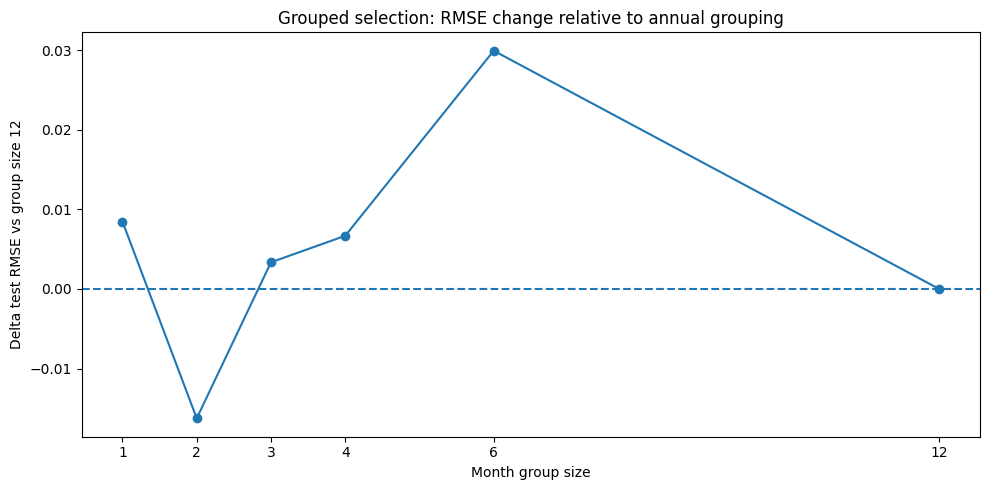

In [27]:
plot_df = delta_view.sort_values("month_group_size").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(plot_df["month_group_size"], plot_df["dRMSE_vs_group12"], marker="o")
plt.axhline(0.0, linestyle="--")
plt.xticks(plot_df["month_group_size"])
plt.xlabel("Month group size")
plt.ylabel("Delta test RMSE vs group size 12")
plt.title("Grouped selection: RMSE change relative to annual grouping")
plt.tight_layout()
save_current_plot("03_training_strategy_grouped_rmse_delta_vs_annual_grouping.png")
plt.show()

### **Plot: MAE delta vs annual grouping**

This plot repeats the same reference comparison using MAE.

Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/03_training_strategy_grouped_mae_delta_vs_annual_grouping.png


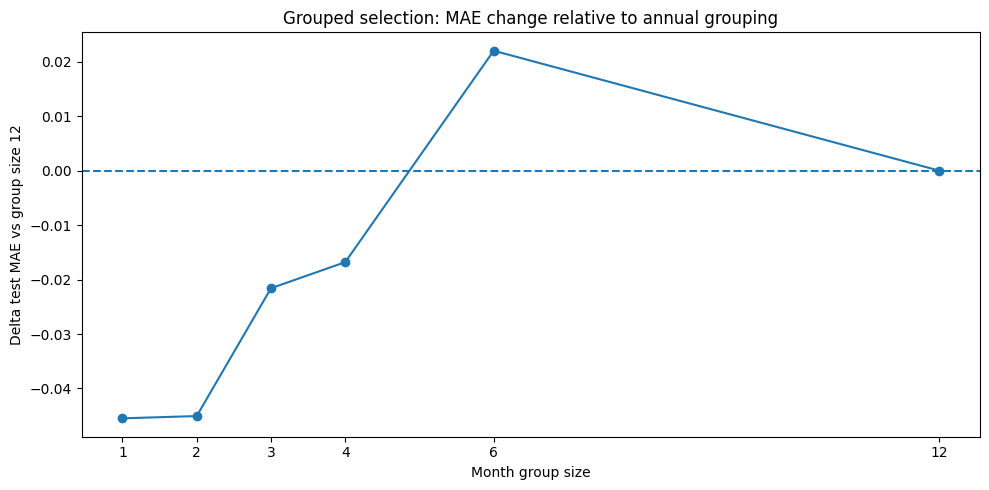

In [28]:
plot_df = delta_view.sort_values("month_group_size").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(plot_df["month_group_size"], plot_df["dMAE_vs_group12"], marker="o")
plt.axhline(0.0, linestyle="--")
plt.xticks(plot_df["month_group_size"])
plt.xlabel("Month group size")
plt.ylabel("Delta test MAE vs group size 12")
plt.title("Grouped selection: MAE change relative to annual grouping")
plt.tight_layout()
save_current_plot("03_training_strategy_grouped_mae_delta_vs_annual_grouping.png")
plt.show()

### **Inspect the choice table for each grouping size**

Choice tables show which model was selected for each month group. This helps explain whether a grouped ensemble is dominated by one model or varies by season.

In [29]:
for g, rr in grouped_run_objects.items():
    print(f"/n===== month_group_size = {g} : choice table =====")
    mct = getattr(rr, "month_choice_table", None)
    if mct is None:
        print("No month_choice_table found in RunResult.")
    else:
        display(mct)


===== month_group_size = 1 : choice table =====


,Group,Winner,Score,RMSE,MAE,Acc,Count,GroupStartMonth,GroupEndMonth
Month,,,,,,,,,
M01,G01_01,NHiTS,0.191915,1.052078,0.811598,0.500,8,1,1
M02,G02_02,Baseline,0.247500,1.486614,1.249835,0.250,8,2,2
M03,G03_03,Ridge,0.288750,1.685039,1.416649,0.125,8,3,3
M04,G04_04,Ridge,0.206250,0.678967,0.582535,0.375,8,4,4
M05,G05_05,XGBoost,0.123750,0.553521,0.437176,0.625,8,5,5
M06,G06_06,PatchTST,0.165000,0.602334,0.499127,0.500,8,6,6
M07,G07_07,PatchTST,0.123750,0.575055,0.461863,0.625,8,7,7
M08,G08_08,NHiTS,0.082500,0.526634,0.391509,0.750,8,8,8
M09,G09_09,Baseline,0.123750,0.627662,0.419676,0.625,8,9,9



===== month_group_size = 2 : choice table =====


,Group,Winner,Score,RMSE,MAE,Acc,Count,GroupStartMonth,GroupEndMonth
Month,,,,,,,,,
M01,G01_02,Ridge,0.226875,1.334963,1.142667,0.3125,16,1,2
M02,G01_02,Ridge,0.226875,1.334963,1.142667,0.3125,16,1,2
M03,G03_04,Ridge,0.247500,1.284592,0.999592,0.2500,16,3,4
M04,G03_04,Ridge,0.247500,1.284592,0.999592,0.2500,16,3,4
M05,G05_06,iTransformer,0.165000,0.668674,0.571800,0.5000,16,5,6
M06,G05_06,iTransformer,0.165000,0.668674,0.571800,0.5000,16,5,6
M07,G07_08,PatchTST,0.123750,0.562186,0.461504,0.6250,16,7,8
M08,G07_08,PatchTST,0.123750,0.562186,0.461504,0.6250,16,7,8
M09,G09_10,Baseline,0.165000,0.749604,0.577107,0.5000,16,9,10



===== month_group_size = 3 : choice table =====


...

,Group,Winner,Score,RMSE,MAE,Acc,Count,GroupStartMonth,GroupEndMonth
Month,,,,,,,,,
M01,G01_04,Ridge,0.237187,1.310020,1.071130,0.28125,32,1,4
M02,G01_04,Ridge,0.237187,1.310020,1.071130,0.28125,32,1,4
M03,G01_04,Ridge,0.237187,1.310020,1.071130,0.28125,32,1,4
M04,G01_04,Ridge,0.237187,1.310020,1.071130,0.28125,32,1,4
M05,G05_08,PatchTST,0.154687,0.626907,0.517492,0.53125,32,5,8
M06,G05_08,PatchTST,0.154687,0.626907,0.517492,0.53125,32,5,8
M07,G05_08,PatchTST,0.154687,0.626907,0.517492,0.53125,32,5,8
M08,G05_08,PatchTST,0.154687,0.626907,0.517492,0.53125,32,5,8
M09,G09_12,Huber,0.206250,1.055193,0.850636,0.37500,32,9,12



===== month_group_size = 6 : choice table =====


,Group,Winner,Score,RMSE,MAE,Acc,Count,GroupStartMonth,GroupEndMonth
Month,,,,,,,,,
M01,G01_06,Ridge,0.213125,1.154901,0.931071,0.354167,48,1,6
M02,G01_06,Ridge,0.213125,1.154901,0.931071,0.354167,48,1,6
M03,G01_06,Ridge,0.213125,1.154901,0.931071,0.354167,48,1,6
M04,G01_06,Ridge,0.213125,1.154901,0.931071,0.354167,48,1,6
M05,G01_06,Ridge,0.213125,1.154901,0.931071,0.354167,48,1,6
M06,G01_06,Ridge,0.213125,1.154901,0.931071,0.354167,48,1,6
M07,G07_12,NHiTS,0.185625,0.930756,0.733121,0.437500,48,7,12
M08,G07_12,NHiTS,0.185625,0.930756,0.733121,0.437500,48,7,12
M09,G07_12,NHiTS,0.185625,0.930756,0.733121,0.437500,48,7,12



===== month_group_size = 12 : choice table =====


,Group,Winner,Score,RMSE,MAE,Acc,Count,GroupStartMonth,GroupEndMonth
Month,,,,,,,,,
M01,G01_12,NHiTS,0.20625,1.061779,0.837982,0.375,96,1,12
M02,G01_12,NHiTS,0.20625,1.061779,0.837982,0.375,96,1,12
M03,G01_12,NHiTS,0.20625,1.061779,0.837982,0.375,96,1,12
M04,G01_12,NHiTS,0.20625,1.061779,0.837982,0.375,96,1,12
M05,G01_12,NHiTS,0.20625,1.061779,0.837982,0.375,96,1,12
M06,G01_12,NHiTS,0.20625,1.061779,0.837982,0.375,96,1,12
M07,G01_12,NHiTS,0.20625,1.061779,0.837982,0.375,96,1,12
M08,G01_12,NHiTS,0.20625,1.061779,0.837982,0.375,96,1,12
M09,G01_12,NHiTS,0.20625,1.061779,0.837982,0.375,96,1,12


### **Full overall validation tables for each run**

In [30]:
SHOW_FULL_VAL_TABLES = False

if SHOW_FULL_VAL_TABLES:
    for g, rr in grouped_run_objects.items():
        print(f"/n===== month_group_size = {g} : FULL VAL TABLE =====")
        display(rr.overall_val.copy().sort_values(["RMSE", "MAE"]).reset_index(drop=True))
else:
    print("Set SHOW_FULL_VAL_TABLES = True if you want to inspect every validation table.")

Set SHOW_FULL_VAL_TABLES = True if you want to inspect every validation table.


### **Full overall test tables for each run**

In [31]:
SHOW_FULL_TEST_TABLES = False

if SHOW_FULL_TEST_TABLES:
    for g, rr in grouped_run_objects.items():
        print(f"/n===== month_group_size = {g} : FULL TEST TABLE =====")
        display(rr.overall_test.copy().sort_values(["RMSE", "MAE"]).reset_index(drop=True))
else:
    print("Set SHOW_FULL_TEST_TABLES = True if you want to inspect every test table.")

Set SHOW_FULL_TEST_TABLES = True if you want to inspect every test table.


### **Compact RMSE / MAE summary**

This small table keeps the core grouped-selection scores visible after the optional full-table diagnostics.

In [32]:
# Build a simple RMSE summary table

rmse_summary = (
    grouped_results_df[["month_group_size", "test_rmse", "test_mae"]]
    .sort_values("month_group_size")
    .reset_index(drop=True)
)

print("Overall RMSE by month group size")
display(rmse_summary)

Overall RMSE by month group size


,month_group_size,test_rmse,test_mae
0,1,1.210470,0.927799
1,2,1.185771,0.928219
2,3,1.205365,0.951686
3,4,1.208692,0.956475
4,6,1.231933,0.995295
5,12,1.202017,0.973281


---

# **Part 7: Seasonal Top-K Strategy Experiment**

### **Seasonal Top-K Strategy Check**

This diagnostic tests whether using more than one top seasonal model would help. It is a stability check on the single-winner month-choice strategy.

In [33]:
selected_group_size = int(best_grouping["month_group_size"])
print("Selected group size for top-k strategy check:", selected_group_size)

valid_cfg_keys = set(ForecasterConfig.__dataclass_fields__.keys())
ensemble_cfg_kwargs = {
    **GROUPED_BASE_CFG,
    "use_month_alpha_choice": False,
    "month_group_size": selected_group_size,
}
ignored_keys = sorted(set(ensemble_cfg_kwargs) - valid_cfg_keys)
if ignored_keys:
    print(f"Ignoring unsupported config keys: {ignored_keys}")
ensemble_cfg = ForecasterConfig(
    **{k: v for k, v in ensemble_cfg_kwargs.items() if k in valid_cfg_keys}
)
ensemble_cfg

Selected group size for top-k strategy check: 2


ForecasterConfig(tavg_file='nclimgrid_tavg.nc', sst_dir='sst_cache', enso_csv='nina34.anom.csv', H=1, K=10, pc_lags=(1, 2, 3, 6, 12), y_lags=(1, 2, 3, 6, 12), ar_lags=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12), enso_lags=(0, 1, 3, 6, 12), use_teleconnections=False, ao_url='https://psl.noaa.gov/data/correlation/ao.data', nao_url='https://psl.noaa.gov/data/correlation/nao.data', pna_url='https://psl.noaa.gov/data/correlation/pna.data', tele_lags=(0, 1, 2, 3, 6, 12), use_sst=False, sst_pc_lags=(0, 1, 3, 6, 12), sst_regions={'TPAC': {'lat': (-30, 30), 'lon': (120, 290), 'k': 8}, 'NPAC': {'lat': (20, 70), 'lon': (110, 260), 'k': 6}, 'NATL': {'lat': (0, 70), 'lon': (280, 360), 'k': 6}, 'IND': {'lat': (-30, 30), 'lon': (40, 110), 'k': 5}}, sst_pcs_cache_files=None, coverage_candidates=(0.95, 0.9, 0.85, 0.8, 0.7, 0.6, 0.5, 0.35, 0.2, 0.1, 0.09), sst_fallback_keep_min=250, sst_fallback_keep_max=5000, random_seed=42, use_recency_weights=True, half_life_months=48.0, use_ridge=True, use_enet=False, u

### **Prepare data for the Top-K diagnostic**

This block rebuilds the fixed grouped-selection problem without automatic month choice so the notebook can manually compare single-winner, Top-2, and Top-3 seasonal strategies.

In [34]:
y_full, y_anom_full, time_index = load_land_series_and_anoms(ensemble_cfg)
y_anom_full = pd.Series(y_anom_full, index=time_index, name="y_anom").sort_index()

enso = load_enso_monthly(ensemble_cfg.enso_csv, time_index) if getattr(ensemble_cfg, "enso_csv", None) else None

ao = nao = pna = None
if bool(getattr(ensemble_cfg, "use_teleconnections", False)):
    ao, nao, pna = load_teleconnections(time_index, ensemble_cfg)

z_sst_multi = None
if bool(getattr(ensemble_cfg, "use_sst", False)):
    z_sst_multi = load_multi_region_sst_pcs(ensemble_cfg, time_index)

split = build_features_and_target(
    cfg=ensemble_cfg,
    y_anom_full=y_anom_full,
    time_index=time_index,
    enso=enso,
    ao=ao,
    nao=nao,
    pna=pna,
    Z_sst_multi=z_sst_multi,
)

pred_val_all, pred_test_all = train_predict_models(ensemble_cfg, split)

print("Train rows:", len(split.X_train))
print("Val rows:", len(split.X_val))
print("Test rows:", len(split.X_test))
print("Candidate models:", sorted(pred_val_all.keys()))

Train rows: 720
Val rows: 96
Test rows: 95
Candidate models: ['Huber', 'LSTM', 'NHiTS', 'PatchTST', 'Ridge', 'XGBoost', 'iTransformer']


### **Build seasonal Top-K strategy tables**

This block ranks retained models inside each selected month group on validation, then builds the Top-1, Top-2, and Top-3 member tables.

In [35]:
SEASON_GROUPS = build_contiguous_month_groups(selected_group_size)

group_rankings = {
    group: rank_models_in_group(
        y_true=split.y_val.values,
        target_idx=split.targ_val,
        pred_dict=pred_val_all,
        months=months,
    )
    for group, months in SEASON_GROUPS.items()
}

strategy_single = build_strategy_table(group_rankings, top_k=1)
strategy_top2 = build_strategy_table(group_rankings, top_k=2)
strategy_top3 = build_strategy_table(group_rankings, top_k=3)

print("Selected month groups:", SEASON_GROUPS)
display(strategy_single)
display(strategy_top2)
display(strategy_top3)

Selected month groups: {'G01_02': [1, 2], 'G03_04': [3, 4], 'G05_06': [5, 6], 'G07_08': [7, 8], 'G09_10': [9, 10], 'G11_12': [11, 12]}


,Group,Members,TopK,Leader,Leader_RMSE
0,G01_02,Ridge,1,Ridge,1.334963
1,G03_04,Ridge,1,Ridge,1.284592
2,G05_06,iTransformer,1,iTransformer,0.668674
3,G07_08,PatchTST,1,PatchTST,0.562186
4,G09_10,NHiTS,1,NHiTS,0.824787
5,G11_12,Huber,1,Huber,1.218576


,Group,Members,TopK,Leader,Leader_RMSE
0,G01_02,"Ridge, Huber",2,Ridge,1.334963
1,G03_04,"Ridge, NHiTS",2,Ridge,1.284592
2,G05_06,"iTransformer, PatchTST",2,iTransformer,0.668674
3,G07_08,"PatchTST, NHiTS",2,PatchTST,0.562186
4,G09_10,"NHiTS, Huber",2,NHiTS,0.824787
5,G11_12,"Huber, NHiTS",2,Huber,1.218576


,Group,Members,TopK,Leader,Leader_RMSE
0,G01_02,"Ridge, Huber, NHiTS",3,Ridge,1.334963
1,G03_04,"Ridge, NHiTS, LSTM",3,Ridge,1.284592
2,G05_06,"iTransformer, PatchTST, NHiTS",3,iTransformer,0.668674
3,G07_08,"PatchTST, NHiTS, iTransformer",3,PatchTST,0.562186
4,G09_10,"NHiTS, Huber, iTransformer",3,NHiTS,0.824787
5,G11_12,"Huber, NHiTS, Ridge",3,Huber,1.218576


### **Create Top-K seasonal predictions**

This block applies each strategy table to the test period. Top-K strategies average the selected members within each target month group.

In [36]:
seasonal_single_pred = make_seasonal_ensemble_prediction(
    targ_idx=split.targ_test,
    pred_test_all=pred_test_all,
    group_member_map=build_group_member_map(strategy_single),
    month_groups=SEASON_GROUPS,
)

seasonal_top2_pred = make_seasonal_ensemble_prediction(
    targ_idx=split.targ_test,
    pred_test_all=pred_test_all,
    group_member_map=build_group_member_map(strategy_top2),
    month_groups=SEASON_GROUPS,
)

seasonal_top3_pred = make_seasonal_ensemble_prediction(
    targ_idx=split.targ_test,
    pred_test_all=pred_test_all,
    group_member_map=build_group_member_map(strategy_top3),
    month_groups=SEASON_GROUPS,
)

print("Seasonal Top-K predictions created for", len(split.targ_test), "test months.")

Seasonal Top-K predictions created for 95 test months.


### **Standalone candidate benchmark for the Top-K diagnostic**

This table ranks the retained standalone models on the same test split used by the seasonal strategies.

In [37]:
overall_test_candidates = overall_table(
    y_true=split.y_test.values,
    pred_dict=pred_test_all,
)

overall_test_candidates = overall_test_candidates.sort_values(["RMSE", "MAE"]).reset_index(drop=True)
overall_test_candidates

,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,PatchTST,1.177713,0.932456,-0.260849,0.189474,0.273684,0.347368
1,NHiTS,1.202017,0.973281,-0.382734,0.147368,0.210526,0.294737
2,iTransformer,1.205905,0.974722,-0.415567,0.115789,0.178947,0.315789
3,Huber,1.222309,0.964794,-0.418343,0.189474,0.210526,0.336842
4,Ridge,1.226889,0.991447,-0.399937,0.084211,0.189474,0.273684
5,LSTM,1.237365,1.001151,-0.428307,0.157895,0.210526,0.273684
6,XGBoost,1.362837,1.105808,-0.408275,0.115789,0.178947,0.273684


### **Compare global and seasonal Top-K strategies**

This table compares the best standalone model with the single-winner and averaged seasonal strategies.

In [38]:
final_rows = []

# Best global model among standalone candidates
best_global = overall_test_candidates.iloc[0]
final_rows.append({
    "strategy": "global_single_best",
    "source": str(best_global["Model"]),
    "test_rmse": float(best_global["RMSE"]),
    "test_mae": float(best_global["MAE"]),
    "test_bias": float(best_global["Bias"]),
})

# Seasonal strategies
for name, pred in [
    ("seasonal_single_best", seasonal_single_pred),
    ("seasonal_top2_mean", seasonal_top2_pred),
    ("seasonal_top3_mean", seasonal_top3_pred),
]:
    final_rows.append({
        "strategy": name,
        "source": "seasonal_ensemble",
        "test_rmse": rmse(split.y_test.values, pred),
        "test_mae": mae(split.y_test.values, pred),
        "test_bias": bias(split.y_test.values, pred),
    })

final_results = pd.DataFrame(final_rows).sort_values(["test_rmse", "test_mae"]).reset_index(drop=True)
final_results

,strategy,source,test_rmse,test_mae,test_bias
0,global_single_best,PatchTST,1.177713,0.932456,-0.260849
1,seasonal_top3_mean,seasonal_ensemble,1.200148,0.957719,-0.351928
2,seasonal_top2_mean,seasonal_ensemble,1.204368,0.956862,-0.356341
3,seasonal_single_best,seasonal_ensemble,1.211879,0.962755,-0.347372


### **Top-K strategy deltas vs global single best**

Negative deltas mean the seasonal strategy improves over the best standalone model in this diagnostic.

In [39]:
ref_rmse = float(final_results.loc[final_results["strategy"] == "global_single_best", "test_rmse"].iloc[0])
ref_mae = float(final_results.loc[final_results["strategy"] == "global_single_best", "test_mae"].iloc[0])

compare_df = final_results.copy()
compare_df["dRMSE_vs_global_single"] = compare_df["test_rmse"] - ref_rmse
compare_df["dMAE_vs_global_single"] = compare_df["test_mae"] - ref_mae

compare_df

,strategy,source,test_rmse,test_mae,test_bias,dRMSE_vs_global_single,dMAE_vs_global_single
0,global_single_best,PatchTST,1.177713,0.932456,-0.260849,0.000000,0.000000
1,seasonal_top3_mean,seasonal_ensemble,1.200148,0.957719,-0.351928,0.022434,0.025264
2,seasonal_top2_mean,seasonal_ensemble,1.204368,0.956862,-0.356341,0.026655,0.024406
3,seasonal_single_best,seasonal_ensemble,1.211879,0.962755,-0.347372,0.034166,0.030299


### **Per-month test performance for the seasonal strategies**

Per-month metrics reveal where the seasonal strategy gains or loses accuracy. This helps identify whether improvements are broad or concentrated in a few months.

In [40]:
per_month_rows = []

for strategy_name, pred in [
    ("seasonal_single_best", seasonal_single_pred),
    ("seasonal_top2_mean", seasonal_top2_pred),
    ("seasonal_top3_mean", seasonal_top3_pred),
]:
    pm = eval_by_month(
        y_true=split.y_test.values,
        y_pred=pred,
        target_idx=split.targ_test,
    ).reset_index().rename(columns={"index": "Month"})
    pm["strategy"] = strategy_name
    per_month_rows.append(pm)

per_month_df = pd.concat(per_month_rows, ignore_index=True)
per_month_df

,mkey,Count,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50,strategy
0,M01,8,1.596727,1.287452,-0.575018,0.000000,0.125000,0.375000,seasonal_single_best
1,M02,8,1.782392,1.478059,0.692938,0.000000,0.125000,0.375000,seasonal_single_best
2,M03,8,1.361526,1.102892,-0.288485,0.125000,0.250000,0.250000,seasonal_single_best
3,M04,8,0.882129,0.764582,0.175265,0.125000,0.250000,0.250000,seasonal_single_best
4,M05,8,0.923085,0.672714,-0.291410,0.000000,0.500000,0.500000,seasonal_single_best
5,M06,8,0.950302,0.811497,-0.731658,0.250000,0.250000,0.250000,seasonal_single_best
6,M07,8,0.491500,0.422663,-0.379282,0.250000,0.375000,0.875000,seasonal_single_best
7,M08,8,0.466679,0.425971,-0.313952,0.250000,0.500000,0.625000,seasonal_single_best
8,M09,8,1.178526,1.077078,-1.061124,0.125000,0.125000,0.125000,seasonal_single_best
9,M10,8,1.061372,0.900665,-0.136457,0.125000,0.125000,0.250000,seasonal_single_best


### **Save results to CSV**

In [41]:
out_dir = PROJECT_ROOT / "notebooks_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

leaderboard_path = out_dir / "03_training_strategy_grouped_leaderboard.csv"
results_path = out_dir / "03_training_strategy_grouped_results.csv"
final_results_path = out_dir / "03_training_strategy_grouped_topk_results.csv"
strategy_single_path = out_dir / "03_training_strategy_grouped_strategy_single.csv"
strategy_top2_path = out_dir / "03_training_strategy_grouped_strategy_top2.csv"
strategy_top3_path = out_dir / "03_training_strategy_grouped_strategy_top3.csv"
per_month_path = out_dir / "03_training_strategy_grouped_topk_per_month.csv"

grouped_leaderboard.to_csv(leaderboard_path, index=False)
grouped_results_df.to_csv(results_path, index=False)
final_results.to_csv(final_results_path, index=False)
strategy_single.to_csv(strategy_single_path, index=False)
strategy_top2.to_csv(strategy_top2_path, index=False)
strategy_top3.to_csv(strategy_top3_path, index=False)
per_month_df.to_csv(per_month_path, index=False)

print("Saved:", project_relative(leaderboard_path))
print("Saved:", project_relative(results_path))
print("Saved:", project_relative(final_results_path))
print("Saved:", project_relative(strategy_single_path))
print("Saved:", project_relative(strategy_top2_path))
print("Saved:", project_relative(strategy_top3_path))
print("Saved:", project_relative(per_month_path))

Saved: notebooks_outputs/03_training_strategy_grouped_leaderboard.csv
Saved: notebooks_outputs/03_training_strategy_grouped_results.csv
Saved: notebooks_outputs/03_training_strategy_grouped_topk_results.csv
Saved: notebooks_outputs/03_training_strategy_grouped_strategy_single.csv
Saved: notebooks_outputs/03_training_strategy_grouped_strategy_top2.csv
Saved: notebooks_outputs/03_training_strategy_grouped_strategy_top3.csv
Saved: notebooks_outputs/03_training_strategy_grouped_topk_per_month.csv


---

# **Part 8: Conclusion**

### **Overall Takeaways:**

- The recency-weighting sweep shows that weighting recent observations improves the selected model's held-out performance relative to the unweighted run. The unweighted strategy had the weakest test result in this section, while every weighted half-life reduced test RMSE.
- The strongest recency result in the current run is half_life_48m: NHiTS is selected on validation, with validation RMSE near 1.062 and test RMSE near 1.202. Shorter and longer half-lives remain competitive, but they do not improve the main leaderboard result here.
- The seasonal strategy check shows that grouped/month-specific model selection does not beat the simpler global model choice. The best strategy table result is global_single_best, with PatchTST producing the lowest test RMSE near 1.178.
- Seasonal ensembles remain useful diagnostics because they show that different month groups can favor different models, but their higher RMSE suggests that month-level specialization is not robust enough to carry as the main selection strategy.
- These results support keeping recency weighting while using a global model-selection strategy instead of seasonal month-choice for the next experiment stage.

---